# LMTL Model — With Spatial Transport

This notebook extends the [no-transport example](01_lmtl_no_transport.ipynb) by
adding **advection and diffusion** on a 2D spatial grid.

**What you will learn:**

1. What the **transport blueprint** adds compared to the no-transport version.
2. How to set up **velocity fields**, **grid metrics**, and **boundary conditions**.
3. How two co-rotating vortices redistribute biomass from a localised NPP source.
4. How **diffusion** smooths spatial gradients.


In [1]:
import time

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import yaml

from seapopym.blueprint import Config
from seapopym.compiler import compile_model
from seapopym.engine import simulate
from seapopym.models import LMTL

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.9.0.1
JAX devices: [CpuDevice(id=0)]


## 1. The Transport Blueprint

The `LMTL` blueprint extends `LMTL_NO_TRANSPORT` with three additions:

1. **Transport forcings** — velocity fields (`u`, `v`), diffusion coefficient (`D`),
   grid metrics (`dx`, `dy`, `face_height`, `face_width`, `cell_area`), an ocean
   `mask`, and boundary condition codes (`bc_north`, etc.).
2. **DVM-weighted velocity** — `layer_weighted_mean` averages `u` and `v` over depth
   layers according to the day/night vertical migration pattern.
3. **Transport tendencies** — `transport_tendency` computes advection + diffusion
   fluxes for both `biomass` and `production`.

These tendencies are added to the Euler integration alongside the biological terms
(mortality, recruitment, NPP, aging).


In [2]:
blueprint = LMTL

# Pretty-print the Blueprint as YAML
bp_dict = blueprint.model_dump(exclude_none=True)
print(yaml.dump(bp_dict, default_flow_style=False, sort_keys=False, width=120))

id: seapodym-lmtl
version: '1.0'
declarations:
  state:
    biomass:
      units: g/m^2
      dims:
      - F
      - Y
      - X
    production:
      units: g/m^2
      dims:
      - F
      - C
      - Y
      - X
  parameters:
    lambda_0:
      units: 1/s
      dims:
      - F
    gamma_lambda:
      units: 1/delta_degC
      dims:
      - F
    tau_r_0:
      units: s
      dims:
      - F
    gamma_tau_r:
      units: 1/delta_degC
      dims:
      - F
    t_ref:
      units: degC
    efficiency:
      units: dimensionless
      dims:
      - F
    cohort_ages:
      units: s
      dims:
      - C
    day_layer:
      units: dimensionless
      dims:
      - F
    night_layer:
      units: dimensionless
      dims:
      - F
  forcings:
    latitude:
      units: degrees
      dims:
      - Y
    temperature:
      units: degC
      dims:
      - T
      - Z
      - Y
      - X
    primary_production:
      units: g/m^2/s
      dims:
      - T
      - Y
      - X
    day_of_yea

### Process DAG

Visualize the computation graph of the blueprint:

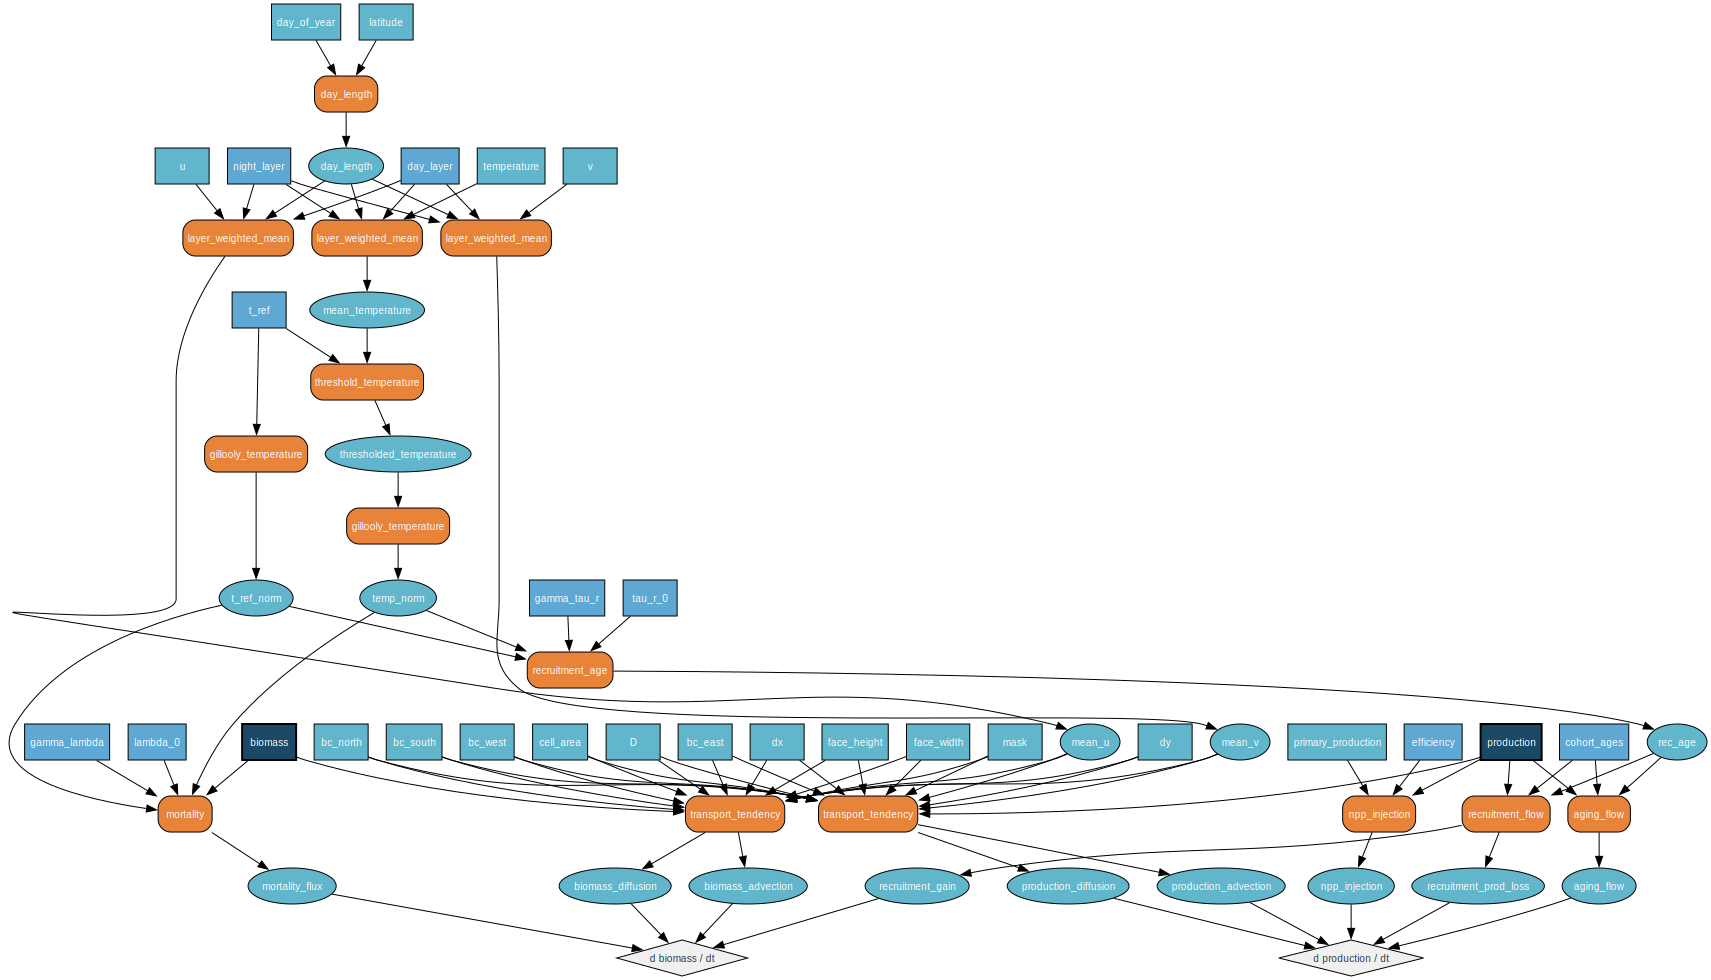

In [3]:
blueprint.to_graphviz()

## 2. Domain Setup

We create a **20×20 grid** (10 km resolution) with:

- **Two co-rotating Rankine vortices** — one in the upper-left corner, one in
  the lower-right corner, spinning in the same direction. Their interaction creates
  a large-scale circulation that sweeps biomass across the domain.
- A **Gaussian NPP blob** — localised primary production at the grid centre, between
  the two vortices.
- **Two small islands** — land patches where the ocean mask is zero.
- **Open boundaries** — material can leave the domain edges.


In [4]:
# --- LMTL parameters (standard values) ---
PARAMS = {
    "lambda_0": 1 / 150 / 86400,
    "gamma_lambda": 0.15,
    "tau_r_0": 10.38 * 86400,
    "gamma_tau_r": 0.11,
    "t_ref": 0.0,
    "efficiency": 0.1668,
}

# --- Grid ---
NY, NX = 20, 20
CELL_SIZE = 10_000.0  # 10 km
N_LAYERS = 1  # single depth layer (no DVM)

# --- Time ---
start_date = "2000-01-01"
end_date = "2002-01-01"  # 2 years (year 1 = spin-up)
DT = "3h"

start_pd = pd.to_datetime(start_date)
end_pd = pd.to_datetime(end_date)
n_days = (end_pd - start_pd).days + 5
dates = pd.date_range(start=start_pd, periods=n_days, freq="D")
doy = dates.dayofyear.values.astype(float)

lat = np.arange(NY, dtype=float)
lon = np.arange(NX, dtype=float)

# --- Cohort ages ---
max_age_days = int(np.ceil(PARAMS["tau_r_0"] / 86400))
cohort_ages_sec = np.arange(0, max_age_days + 1) * 86400.0
n_cohorts = len(cohort_ages_sec)

print(f"Grid: {NY}×{NX}, cell size = {CELL_SIZE / 1000:.0f} km")
print(f"Simulation: {start_date} → {end_date} (dt={DT})")
print(f"Cohorts: {n_cohorts} (max age = {max_age_days} days)")

Grid: 20×20, cell size = 10 km
Simulation: 2000-01-01 → 2002-01-01 (dt=3h)
Cohorts: 12 (max age = 11 days)


## 3. Forcings

### Temperature & NPP

Temperature is uniform across the grid but varies seasonally. NPP is a **Gaussian
blob** centered on the domain — production is strongest at the centre and decays
radially.

### Dual Counter-Rotating Vortices

Each vortex follows a [Rankine profile](https://en.wikipedia.org/wiki/Rankine_vortex):

- **Inside** the core radius: solid-body rotation (`v ∝ r`)
- **Outside** the core radius: irrotational decay (`v ∝ 1/r`)

The two vortices spin in **the same direction**, creating a large-scale circulation.
Biomass produced at the centre is swept around both vortex cores and redistributed
across the domain.


In [5]:
# --- Temperature: seasonal, spatially uniform, 1 layer ---
temp_1d = 5.0 + 5.0 * np.sin(2 * np.pi * doy / 365.0)
temp_4d = np.broadcast_to(temp_1d[:, None, None, None], (len(dates), N_LAYERS, NY, NX))

# --- NPP: Gaussian blob with seasonal modulation ---
NPP_PEAK = 2.0 / 86400.0  # g/m²/s
NPP_SIGMA = 3.0  # cells

yy, xx = np.meshgrid(lat, lon, indexing="ij")
npp_spatial = NPP_PEAK * np.exp(-((yy - NY / 2) ** 2 + (xx - NX / 2) ** 2) / (2 * NPP_SIGMA**2))
seasonal = 1.0 + 0.5 * np.sin(2 * np.pi * doy / 365.0)
npp_3d = seasonal[:, None, None] * npp_spatial[None, :, :]

# --- Two co-rotating Rankine vortices ---
VORTEX_VMAX = 0.05  # m/s max tangential velocity
VORTEX_RADIUS = 4  # cells


def rankine_vortex(yy, xx, cy, cx, vmax, r_cells, cell_size, sign=1.0):
    """Compute (u, v) for a single Rankine vortex."""
    dy_g = (yy - cy) * cell_size
    dx_g = (xx - cx) * cell_size
    r = np.sqrt(dx_g**2 + dy_g**2)
    r = np.maximum(r, 1e-6)
    r_max = r_cells * cell_size
    v_tan = np.where(r <= r_max, vmax * r / r_max, vmax * r_max / r)
    u = -sign * v_tan * dy_g / r  # zonal
    v = sign * v_tan * dx_g / r  # meridional
    return u, v


# Vortex 1: upper-left, counter-clockwise (+1)
u1, v1 = rankine_vortex(yy, xx, cy=5.0, cx=5.0, vmax=VORTEX_VMAX, r_cells=VORTEX_RADIUS, cell_size=CELL_SIZE, sign=+1.0)

# Vortex 2: lower-right, counter-clockwise (+1)
u2, v2 = rankine_vortex(
    yy, xx, cy=15.0, cx=15.0, vmax=VORTEX_VMAX, r_cells=VORTEX_RADIUS, cell_size=CELL_SIZE, sign=+1.0
)

# Superpose the two velocity fields
u_field = u1 + u2
v_field = v1 + v2

# Broadcast to (T, Z, Y, X) — stationary
u_4d = np.broadcast_to(u_field[None, None, :, :], (len(dates), N_LAYERS, NY, NX))
v_4d = np.broadcast_to(v_field[None, None, :, :], (len(dates), N_LAYERS, NY, NX))

# --- Grid metrics (uniform rectangular) ---
dx_arr = np.full((NY, NX), CELL_SIZE)
dy_arr = np.full((NY, NX), CELL_SIZE)
cell_area = dx_arr * dy_arr

# --- Ocean mask with 2 islands ---
mask = np.ones((NY, NX))
mask[3:5, 10:12] = 0.0  # island near the centre-top
mask[15:17, 8:10] = 0.0  # island near the centre-bottom

print(f"Vortex 1: centre=(5, 5), CCW, Vmax={VORTEX_VMAX} m/s")
print(f"Vortex 2: centre=(15, 15), CCW, Vmax={VORTEX_VMAX} m/s")
print(f"NPP: peak={NPP_PEAK * 86400:.1f} g/m²/day, sigma={NPP_SIGMA} cells")
print(f"Islands: 2 × 2×2 blocks ({int(mask.sum())}/{NY * NX} ocean cells)")

Vortex 1: centre=(5, 5), CCW, Vmax=0.05 m/s
Vortex 2: centre=(15, 15), CCW, Vmax=0.05 m/s
NPP: peak=2.0 g/m²/day, sigma=3.0 cells
Islands: 2 × 2×2 blocks (392/400 ocean cells)


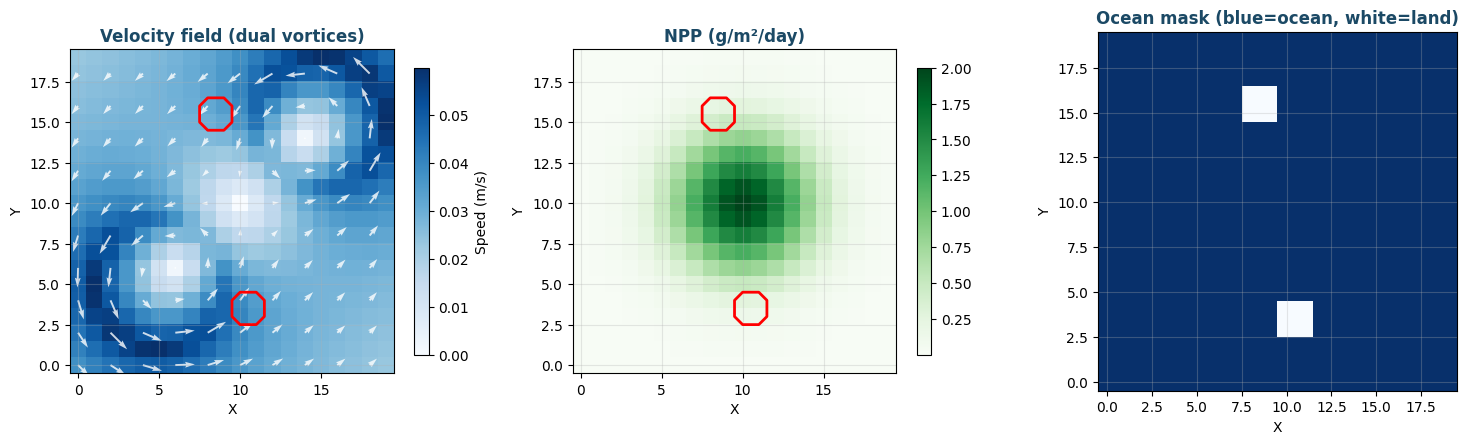

In [6]:
# Visualise the domain setup
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Velocity field ---
ax = axes[0]
speed = np.sqrt(u_field**2 + v_field**2)
im = ax.imshow(speed, origin="lower", cmap="Blues")
skip = 2
ax.quiver(
    xx[::skip, ::skip],
    yy[::skip, ::skip],
    u_field[::skip, ::skip],
    v_field[::skip, ::skip],
    color="white",
    alpha=0.8,
    scale=0.8,
)
ax.contour(mask, levels=[0.5], colors="red", linewidths=2)
ax.set_title("Velocity field (dual vortices)", color="#1B4965", fontweight="bold")
fig.colorbar(im, ax=ax, label="Speed (m/s)", shrink=0.8)

# --- NPP ---
ax = axes[1]
im = ax.imshow(npp_spatial * 86400, origin="lower", cmap="Greens")
ax.contour(mask, levels=[0.5], colors="red", linewidths=2)
ax.set_title("NPP (g/m²/day)", color="#1B4965", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)

# --- Mask ---
ax = axes[2]
ax.imshow(mask, origin="lower", cmap="Blues")
ax.set_title("Ocean mask (blue=ocean, white=land)", color="#1B4965", fontweight="bold")

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

fig.tight_layout()
plt.show()

## 4. Configuration & Compilation

The Config for the transport model includes all the biological parameters **plus**
the transport forcings: velocities, grid metrics, mask, and boundary conditions.

Boundary condition codes:

- `0` = **CLOSED** — no-flux (Neumann)
- `1` = **OPEN** — zero-gradient
- `2` = **PERIODIC** — wrap-around


In [7]:
DIFFUSIVITY = 100.0  # m²/s — moderate diffusion

config = Config(
    parameters={
        "lambda_0": xr.DataArray([PARAMS["lambda_0"]], dims=["F"]),
        "gamma_lambda": xr.DataArray([PARAMS["gamma_lambda"]], dims=["F"]),
        "tau_r_0": xr.DataArray([PARAMS["tau_r_0"]], dims=["F"]),
        "gamma_tau_r": xr.DataArray([PARAMS["gamma_tau_r"]], dims=["F"]),
        "t_ref": xr.DataArray(PARAMS["t_ref"]),
        "efficiency": xr.DataArray([PARAMS["efficiency"]], dims=["F"]),
        "cohort_ages": xr.DataArray(cohort_ages_sec, dims=["C"]),
        "day_layer": xr.DataArray([0], dims=["F"]),
        "night_layer": xr.DataArray([0], dims=["F"]),
    },
    forcings={
        "latitude": xr.DataArray(np.full(NY, 30.0), dims=["Y"], coords={"Y": lat}),
        "temperature": xr.DataArray(
            temp_4d,
            dims=["T", "Z", "Y", "X"],
            coords={"T": dates, "Z": np.arange(N_LAYERS), "Y": lat, "X": lon},
        ),
        "primary_production": xr.DataArray(
            npp_3d,
            dims=["T", "Y", "X"],
            coords={"T": dates, "Y": lat, "X": lon},
        ),
        "day_of_year": xr.DataArray(doy, dims=["T"], coords={"T": dates}),
        # --- Transport forcings ---
        "u": xr.DataArray(
            u_4d,
            dims=["T", "Z", "Y", "X"],
            coords={"T": dates, "Z": np.arange(N_LAYERS), "Y": lat, "X": lon},
        ),
        "v": xr.DataArray(
            v_4d,
            dims=["T", "Z", "Y", "X"],
            coords={"T": dates, "Z": np.arange(N_LAYERS), "Y": lat, "X": lon},
        ),
        "D": xr.DataArray(DIFFUSIVITY),
        "dx": xr.DataArray(dx_arr, dims=["Y", "X"], coords={"Y": lat, "X": lon}),
        "dy": xr.DataArray(dy_arr, dims=["Y", "X"], coords={"Y": lat, "X": lon}),
        "face_height": xr.DataArray(dy_arr, dims=["Y", "X"], coords={"Y": lat, "X": lon}),
        "face_width": xr.DataArray(dx_arr, dims=["Y", "X"], coords={"Y": lat, "X": lon}),
        "cell_area": xr.DataArray(cell_area, dims=["Y", "X"], coords={"Y": lat, "X": lon}),
        "mask": xr.DataArray(mask, dims=["Y", "X"], coords={"Y": lat, "X": lon}),
        "bc_north": xr.DataArray(1),  # OPEN
        "bc_south": xr.DataArray(1),
        "bc_east": xr.DataArray(1),
        "bc_west": xr.DataArray(1),
    },
    initial_state={
        "biomass": xr.DataArray(
            np.zeros((1, NY, NX)),
            dims=["F", "Y", "X"],
            coords={"Y": lat, "X": lon},
        ),
        "production": xr.DataArray(
            np.zeros((1, n_cohorts, NY, NX)),
            dims=["F", "C", "Y", "X"],
            coords={"Y": lat, "X": lon},
        ),
    },
    execution={
        "time_start": start_date,
        "time_end": end_date,
        "dt": DT,
        "forcing_interpolation": "linear",
    },
)

t0 = time.time()
model = compile_model(blueprint, config)
compile_time = time.time() - t0

print(f"Compilation: {compile_time:.2f}s")
print(f"  Timesteps:  {model.n_timesteps}")
print(f"  dt:         {model.dt:.0f}s ({model.dt / 3600:.1f}h)")
print(f"  Diffusivity: {DIFFUSIVITY} m²/s")

Compilation: 0.05s
  Timesteps:  5848
  dt:         10800s (3.0h)
  Diffusivity: 100.0 m²/s


## 5. Simulation

We export both `biomass` and `production`. On a 20×20 grid with 3-hour timesteps
over 2 years, the simulation runs in a few seconds on CPU.


In [8]:
t0 = time.time()
state, outputs = simulate(model, chunk_size=800, export_variables=["biomass", "production"])
sim_time = time.time() - t0

print(f"Simulation: {sim_time:.2f}s ({model.n_timesteps} timesteps)")
print("\nOutputs:")
print(outputs)

Simulation: 0.80s (5848 timesteps)

Outputs:
<xarray.Dataset> Size: 122MB
Dimensions:     (T: 5848, F: 1, Y: 20, X: 20, C: 12)
Coordinates:
  * T           (T) datetime64[us] 47kB 2000-01-01 ... 2001-12-31T21:00:00
  * Y           (Y) float64 160B 0.0 1.0 2.0 3.0 4.0 ... 16.0 17.0 18.0 19.0
Dimensions without coordinates: F, X, C
Data variables:
    biomass     (T, F, Y, X) float32 9MB 0.0 0.0 0.0 0.0 ... 3.76 3.992 4.226
    production  (T, F, C, Y, X) float32 112MB 6.286e-07 1.806e-06 ... 4.331e-20


## 6. Biomass Snapshots

Monthly snapshots of **year 2** (after spin-up) show the spatial biomass
distribution shaped by the two co-rotating vortices. The NPP source at the
centre feeds production that is stretched along the diagonal connecting the two
vortex cores and wrapped into spiral arms.


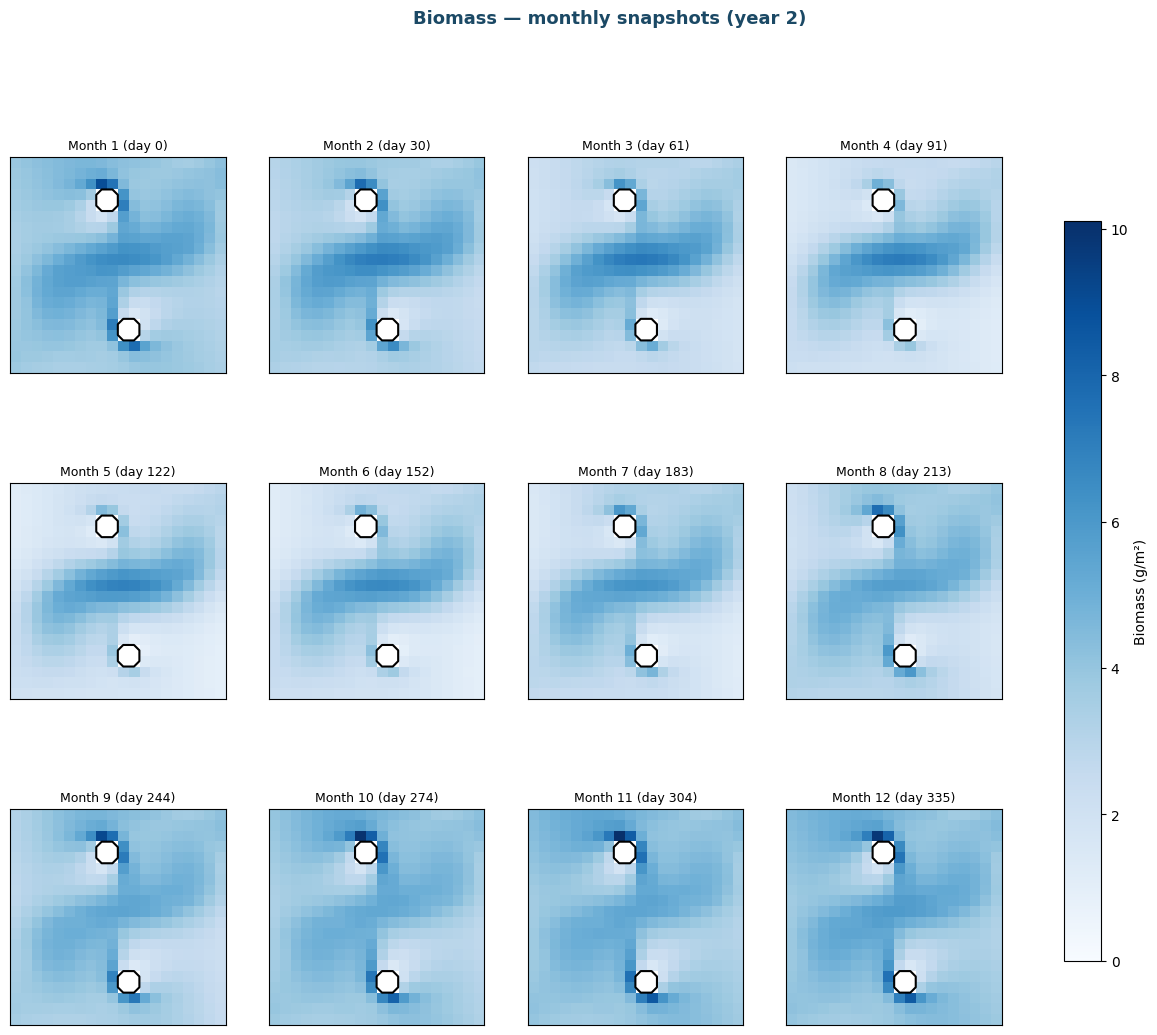

In [9]:
biomass = outputs["biomass"]  # (T, F, Y, X)
time_coords = biomass.coords["T"].values
n_timesteps = len(time_coords)

# Year 2 starts roughly at the midpoint
year2_start = np.searchsorted(time_coords, np.datetime64("2001-01-01"))
dt_sec = float(model.dt)

# 12 monthly snapshots
month_indices = [year2_start + int(m * 30.44 * 86400 / dt_sec) for m in range(12)]
month_indices = [min(i, n_timesteps - 1) for i in month_indices]

biomass_np = biomass.values[:, 0, :, :]  # (T, Y, X) — squeeze F dimension

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
vmin = float(np.nanmin(biomass_np[month_indices]))
vmax = float(np.nanmax(biomass_np[month_indices]))

for idx, (ax, t_idx) in enumerate(zip(axes.flat, month_indices, strict=False)):
    biomass_masked = np.where(mask, biomass_np[t_idx], np.nan)
    im = ax.imshow(biomass_masked, origin="lower", vmin=vmin, vmax=vmax, cmap="Blues")
    ax.contour(mask, levels=[0.5], colors="k", linewidths=1.5)
    day_offset = (t_idx - year2_start) * dt_sec / 86400.0
    ax.set_title(f"Month {idx + 1} (day {day_offset:.0f})", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Biomass — monthly snapshots (year 2)", fontsize=13, color="#1B4965", fontweight="bold")
fig.colorbar(im, ax=axes, label="Biomass (g/m²)", shrink=0.8)
plt.show()

## 7. Biomass Time Series

We compare biomass at three locations:

- **Centre** (10, 10) — directly under the NPP source
- **Near vortex 1** (5, 5) — upper-left vortex core
- **Near vortex 2** (15, 15) — lower-right vortex core

The vortex cores receive biomass advected from the central NPP source. Seasonal
NPP modulation creates oscillations at all three points, but with different
amplitudes and phases depending on the advection path.


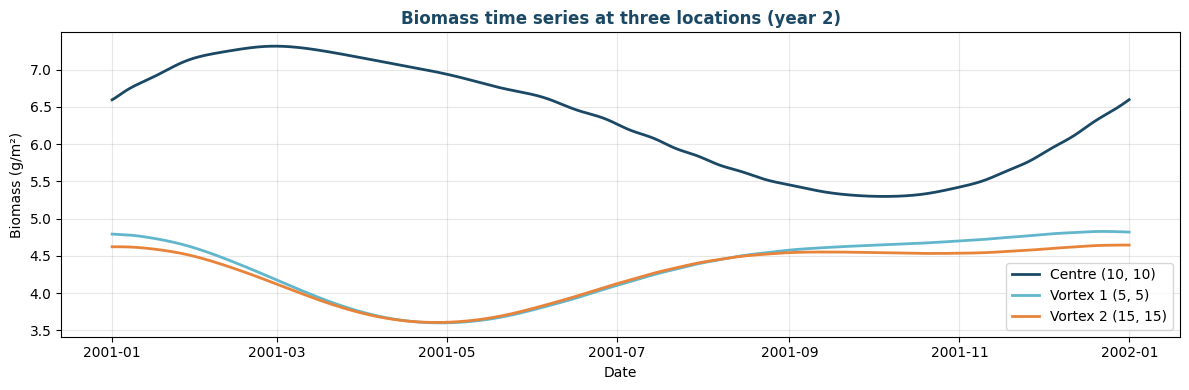

Centre (10, 10): [5.298051, 7.314120] g/m²
Vortex 1 (5, 5): [3.601411, 4.828419] g/m²
Vortex 2 (15, 15): [3.607173, 4.645468] g/m²


In [10]:
# Extract year 2
year2_mask = time_coords >= np.datetime64("2001-01-01")
year2_dates = time_coords[year2_mask]

locations = [
    ("Centre (10, 10)", 10, 10),
    ("Vortex 1 (5, 5)", 5, 5),
    ("Vortex 2 (15, 15)", 15, 15),
]

fig, ax = plt.subplots(figsize=(12, 4))
for idx, (label, py, px) in enumerate(locations):
    bio = biomass_np[year2_mask, py, px]
    ax.plot(year2_dates, bio, linewidth=2, label=label, color=PALETTE[idx])

ax.set_ylabel("Biomass (g/m²)")
ax.set_xlabel("Date")
ax.set_title("Biomass time series at three locations (year 2)", color="#1B4965", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

for label, py, px in locations:
    bio = biomass_np[year2_mask, py, px]
    print(f"{label}: [{bio.min():.6f}, {bio.max():.6f}] g/m²")

## 8. Effect of Diffusion

To see the effect of diffusion, we re-run the simulation with **D = 0** (advection
only) and compare the final biomass field. Without diffusion, spatial gradients are
sharper — the spiral arms are thinner and more distinct.


Simulation (D=0): 0.62s


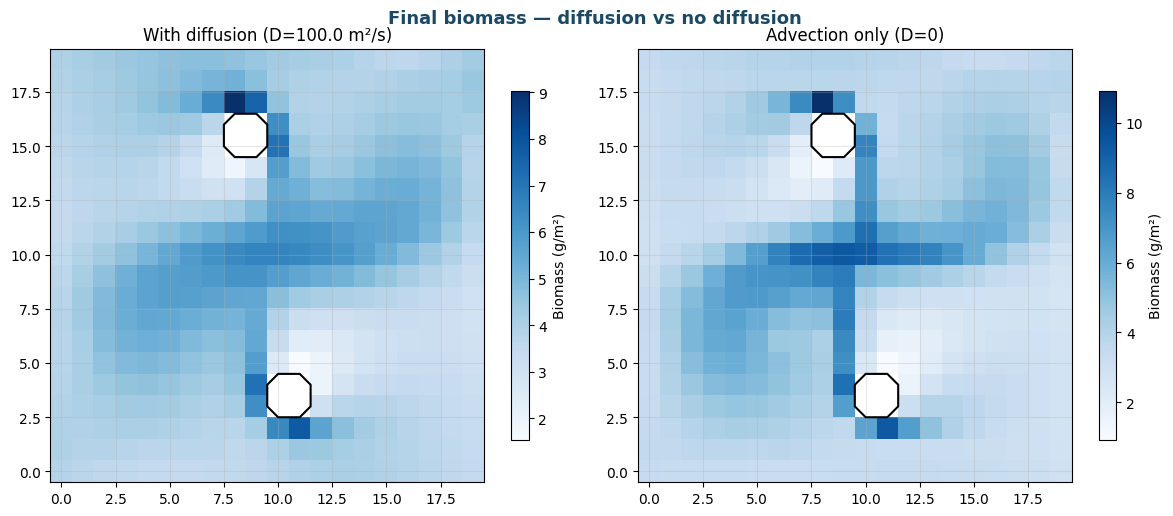

In [11]:
# Re-compile with D = 0
config_no_diff = Config(
    parameters=config.parameters,
    forcings={**config.forcings, "D": xr.DataArray(0.0)},
    initial_state=config.initial_state,
    execution=config.execution,
)

model_no_diff = compile_model(blueprint, config_no_diff)

t0 = time.time()
_, outputs_no_diff = simulate(model_no_diff, chunk_size=800, export_variables=["biomass"])
print(f"Simulation (D=0): {time.time() - t0:.2f}s")

biomass_no_diff = outputs_no_diff["biomass"].values[:, 0, :, :]  # (T, Y, X)

# Compare final timestep
final_idx = n_timesteps - 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(
    axes,
    [biomass_np[final_idx], biomass_no_diff[final_idx]],
    [f"With diffusion (D={DIFFUSIVITY} m²/s)", "Advection only (D=0)"],
    strict=False,
):
    masked = np.where(mask, data, np.nan)
    im = ax.imshow(masked, origin="lower", cmap="Blues")
    ax.contour(mask, levels=[0.5], colors="k", linewidths=1.5)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Biomass (g/m²)", shrink=0.8)

fig.suptitle("Final biomass — diffusion vs no diffusion", fontsize=13, color="#1B4965", fontweight="bold")
fig.tight_layout()
plt.show()

## Summary

| Feature          | No Transport        | With Transport                           |
| ---------------- | ------------------- | ---------------------------------------- |
| Blueprint        | `LMTL_NO_TRANSPORT` | `LMTL`                                   |
| Extra forcings   | —                   | `u`, `v`, `D`, grid metrics, `mask`, BCs |
| Spatial dynamics | Local only          | Advection + diffusion                    |
| Transport scheme | —                   | Upwind (mass-conservative)               |
| DVM weighting    | —                   | `layer_weighted_mean` on velocities      |

**Key takeaways:**

- Transport adds **spatial redistribution** to the biological dynamics.
- **Two co-rotating vortices** create a large-scale circulation that sweeps
  biomass from the central NPP source around each vortex core.
- **Diffusion** smooths gradients — without it, the spiral arms are thinner and
  sharper, but the upwind scheme still introduces some numerical diffusion.
- **Islands** (mask = 0) block transport and create asymmetric patterns.

**Next steps:**

- [Benchmark](03_optimization.ipynb) — Compare Gradient, GA & CMA-ES optimizers.
